https://github.com/selfedu-rus/neuro-pytorch/blob/main/neuro_net_52_gan.py

https://proproprogs.ru/nn_pytorch/pytorch-generativno-sostyazatelnye-seti-gan

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
import torch
import torch.utils.data as data
import torchvision
import torchvision.transforms.v2 as tfs_v2
import torch.nn as nn
import torch.optim as optim

In [2]:
class DigitDataset(data.Dataset):
    def __init__(self, path, train=True, target=5, transform=None):
        _dataset = torchvision.datasets.MNIST(path, download=True, train=train)
        self.dataset = _dataset.data[_dataset.targets == target]
        self.length = self.dataset.size(0)
        self.target = torch.tensor([target], dtype=torch.float32)

        if transform:
            self.dataset = transform(self.dataset).view(-1, 1, 28, 28)

    def __getitem__(self, item):
        return self.dataset[item], self.target

    def __len__(self):
        return self.length

In [3]:
model_gen = nn.Sequential(
    nn.Linear(2, 512*7*7, bias=False),
    nn.ELU(inplace=True),
    nn.BatchNorm1d(512*7*7),
    nn.Unflatten(1, (512, 7, 7)),
    nn.Conv2d(512, 256, 5, 1, padding='same', bias=False),
    nn.ELU(inplace=True),
    nn.BatchNorm2d(256),
    nn.Conv2d(256, 128, 5, 1, padding='same', bias=False),
    nn.ELU(inplace=True),
    nn.BatchNorm2d(128),
    nn.ConvTranspose2d(128, 64, 4, 2, padding=1, bias=False),
    nn.ELU(inplace=True),
    nn.BatchNorm2d(64),
    nn.ConvTranspose2d(64, 32, 4, 2, padding=1, bias=False),
    nn.ELU(inplace=True),
    nn.BatchNorm2d(32),
    nn.Conv2d(32, 1, 1, 1),
    nn.Sigmoid()
)

model_dis = nn.Sequential(
    nn.Conv2d(1, 64, 5, 2, padding=2, bias=False),
    nn.ELU(inplace=True),
    nn.BatchNorm2d(64),
    nn.Conv2d(64, 128, 5, 2, padding=2, bias=False),
    nn.ELU(inplace=True),
    nn.BatchNorm2d(128),
    nn.Flatten(),
    nn.Linear(128*7*7, 1),
)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model_gen.to(device)
model_dis.to(device)

cuda


Sequential(
  (0): Conv2d(1, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
  (1): ELU(alpha=1.0, inplace=True)
  (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
  (4): ELU(alpha=1.0, inplace=True)
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=6272, out_features=1, bias=True)
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 527kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]
Epoch [1/20], loss_mean_gen=6.273, loss_mean_dis=0.118: 100%|██████████| 338/338 [00:10<00:00, 31.78it/s]
Epoch [2/20], loss_mean_gen=8.171, loss_mean_dis=0.248: 100%|██████████| 338/338 [00:08<00:00, 38.90it/s]
Epoch [3/20], loss_mean_gen=6.694, loss_mean_dis=0.134: 100%|██████████| 338/338 [00:08<00:00, 38.88it/s]
Epoch [4/20], loss_mean_gen=6.148, loss_mean_dis=0.136: 100%|██████████| 338/338 [00:08<00:00, 38.78it/s]
Epoch [5/20], loss_mean_gen=5.918, loss_mean_dis=0.134: 100%|██████████| 338/338 [00:08<00:00, 38.63it/s]
Epoch [6/20], loss_mean_gen=5.899, loss_mean_dis=0.196: 100%|██████████| 338/338 [00:08<00:00, 38.43it/s]
Epoch [7/20], loss_mean_gen=6.578, loss_mean_dis=0.274: 100%|██████████| 338/338 [00:08<00:00, 38.30it/s]
Epoch [8/20], loss_mean_gen=4.831, loss_mean_di

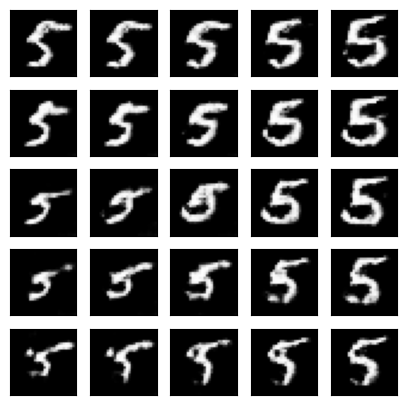

In [ ]:
epochs = 20
hidden_dim = 2
batch_size = 16

transforms = tfs_v2.Compose([tfs_v2.ToImage(), tfs_v2.ToDtype(dtype=torch.float32, scale=True)])
d_train = DigitDataset('../18_Neural_learning_problems/MNIST_data', train=True, transform=transforms)
train_data = data.DataLoader(d_train, batch_size=batch_size, shuffle=True, drop_last=True)

optimizer_gen = optim.Adam(params=model_gen.parameters(), lr=0.001)
optimizer_dis = optim.Adam(params=model_dis.parameters(), lr=0.001)
loss_func = nn.BCEWithLogitsLoss()

targets_0 = torch.zeros(batch_size, 1).to(device)
targets_1 = torch.ones(batch_size, 1).to(device)

loss_gen_lst = []
loss_dis_lst = []

model_gen.train()
model_dis.train()

for _e in range(epochs):
    loss_mean_gen = 0
    loss_mean_dis = 0
    lm_count = 0

    train_tqdm = tqdm(train_data, leave=True)
    for x_train, y_train in train_tqdm:
        x_train = x_train.to(device)

        h = torch.normal(mean=torch.zeros((batch_size, hidden_dim)), std=torch.ones((batch_size, hidden_dim)))
        h = h.to(device)

        img_gen = model_gen(h)
        fake_out = model_dis(img_gen)

        loss_gen = loss_func(fake_out, targets_1)

        optimizer_gen.zero_grad()
        loss_gen.backward()
        optimizer_gen.step()

        # discriminator learning
        img_gen = model_gen(h)
        fake_out = model_dis(img_gen)
        real_out = model_dis(x_train)

        outputs = torch.cat([real_out, fake_out], dim=0).to(device)
        targets = torch.cat([targets_1, targets_0], dim=0).to(device)

        loss_dis = loss_func(outputs, targets)

        optimizer_dis.zero_grad()
        loss_dis.backward()
        optimizer_dis.step()

        lm_count += 1
        loss_mean_gen = 1/lm_count * loss_gen.item() + (1 - 1/lm_count) * loss_mean_gen
        loss_mean_dis = 1/lm_count * loss_dis.item() + (1 - 1/lm_count) * loss_mean_dis

        train_tqdm.set_description(f"Epoch [{_e+1}/{epochs}], loss_mean_gen={loss_mean_gen:.3f}, loss_mean_dis={loss_mean_dis:.3f}")

    loss_gen_lst.append(loss_mean_gen)
    loss_dis_lst.append(loss_mean_dis)

st = model_gen.state_dict()
torch.save(st, 'model_gen.tar')

st = model_dis.state_dict()
torch.save(st, 'model_dis.tar')

st = {'loss_gen': loss_gen_lst, 'loss_dis': loss_dis_lst}
torch.save(st, 'model_gan_losses.tar')

# st = torch.load('model_gen.tar', weights_only=True)
# model_gen.load_state_dict(st)

model_gen.eval()
n = 2
total = 2*n+1

plt.figure(figsize=(total, total))

num = 1
for i in range(-n, n+1):
  for j in range(-n, n+1):
    ax = plt.subplot(total, total, num)
    num += 1
    h = torch.tensor([[1 * i / n, 1 * j / n]], dtype=torch.float32)
    predict = model_gen(h.to(device))
    predict = predict.detach().squeeze()
    dec_img = predict.cpu().numpy()

    plt.imshow(dec_img, cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()